In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/Brain Tumor MRI Dataset.zip" -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/Training/glioma/Tr-gl_279.jpg  
  inflating: /content/Training/glioma/Tr-gl_28.jpg  
  inflating: /content/Training/glioma/Tr-gl_280.jpg  
  inflating: /content/Training/glioma/Tr-gl_281.jpg  
  inflating: /content/Training/glioma/Tr-gl_282.jpg  
  inflating: /content/Training/glioma/Tr-gl_283.jpg  
  inflating: /content/Training/glioma/Tr-gl_284.jpg  
  inflating: /content/Training/glioma/Tr-gl_285.jpg  
  inflating: /content/Training/glioma/Tr-gl_286.jpg  
  inflating: /content/Training/glioma/Tr-gl_287.jpg  
  inflating: /content/Training/glioma/Tr-gl_288.jpg  
  inflating: /content/Training/glioma/Tr-gl_289.jpg  
  inflating: /content/Training/glioma/Tr-gl_29.jpg  
  inflating: /content/Training/glioma/Tr-gl_290.jpg  
  inflating: /content/Training/glioma/Tr-gl_291.jpg  
  inflating: /content/Training/glioma/Tr-gl_292.jpg  
  inflating: /content/Training/glioma/Tr-gl_293.jpg  
  inflating: /content/Training/gl

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights

from torch.utils.data import DataLoader

from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import numpy as np

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5],
                         [0.5,0.5,0.5])
])

In [6]:
train_dataset = datasets.ImageFolder("/content/Training",transform=transform)
test_dataset = datasets.ImageFolder("/content/Testing",transform=transform)

train_loader = DataLoader(train_dataset,batch_size=32,shuffle=True)

test_loader = DataLoader(test_dataset,batch_size=32)

In [7]:
print(train_dataset.classes)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [8]:
weights = ResNet18_Weights.DEFAULT

model = resnet18(weights=weights)

model.fc = nn.Linear(model.fc.in_features,4)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 123MB/s]


In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(),lr=0.0001)

In [10]:
epochs=3

for epoch in range(epochs):

    model.train()

    running_loss=0

    for images,labels in train_loader:

        images=images.to(device)
        labels=labels.to(device)

        optimizer.zero_grad()

        outputs=model(images)

        loss=criterion(outputs,labels)

        loss.backward()

        optimizer.step()

        running_loss+=loss.item()

    print(f"Epoch {epoch+1} Loss {running_loss/len(train_loader):.4f}")

Epoch 1 Loss 0.2270
Epoch 2 Loss 0.0394
Epoch 3 Loss 0.0322


In [11]:
model.eval()

correct=0

total=0

predictions=[]

actual=[]

with torch.no_grad():

    for images,labels in test_loader:

        images=images.to(device)
        labels=labels.to(device)

        outputs=model(images)

        _,pred=torch.max(outputs,1)

        total+=labels.size(0)

        correct+=(pred==labels).sum().item()

        predictions.extend(pred.cpu().numpy())

        actual.extend(labels.cpu().numpy())

accuracy=100*correct/total

print("Accuracy:",accuracy)

Accuracy: 93.125


In [12]:
print(classification_report(actual,predictions,
target_names=train_dataset.classes))

              precision    recall  f1-score   support

      glioma       0.99      0.77      0.87       400
  meningioma       0.85      0.98      0.91       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.99      0.97      0.98       400

    accuracy                           0.93      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.94      0.93      0.93      1600



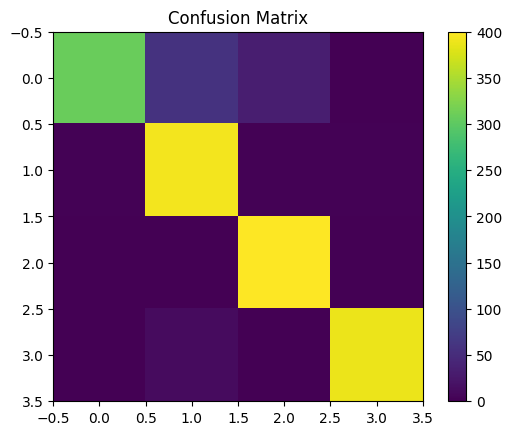

In [13]:
cm=confusion_matrix(actual,predictions)

plt.imshow(cm)

plt.colorbar()

plt.title("Confusion Matrix")

plt.show()

In [14]:
torch.save(model.state_dict(),"brain_model.pth")